## Analysis 1 - Revenue and growth Trend

**Business question** Is this business growing and is there a measurable seasonality in purchase behavior?

### Final findings 
This analysis evaluates monthly revenue trends using 20 complete months of data from the Olist marketplace (January 2017 to August 2018), excluding partial months to avoid distortion.

Revenue shows *strong upward growth*, increasing from **R$9.27M in 2017 to R$11.13M** in the first eight months of 2018 (+20.1%). While annualising 2018 suggests substantially higher growth, this projection assumes stable revenue across the remaining months , an assumption that may not hold given observed volatility and seasonality.

A pronounced revenue spike occurs in **November 2017 (R$1.6M, +55% MoM)**, consistent with Black Friday effects, followed by a **sharp contraction in December (-34%)**, indicating post-promotion demand pull-forward rather than sustained growth.

Contrary to typical Northern Hemisphere retail patterns, peak revenue months are concentrated mid-year (May–August). However, interpretation is constrained by incomplete late-2018 data, limiting direct month-to-month comparability.

Growth dynamics shift over time: early 2017 exhibits hypergrowth **(up to +85% MoM)**, while 2018 stabilises to low single-digit growth, suggesting a transition from rapid expansion to a more mature revenue phase.

Overall, the platform demonstrates strong growth with emerging signs of maturation, event-driven revenue spikes, and locally specific seasonal patterns.




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
master = pd.read_csv('../data/processed/master.csv',
                     parse_dates=['order_purchase_timestamp',
                                   'order_delivered_customer_date', 'order_estimated_delivery_date', ])
rfm_base = pd.read_csv('../data/processed/rfm_base.csv')

COLOUR_PRIMARY = '#14213d'
COLOUR_ACCENT =  '#415a77'
COLOUR_HIGHLIGHT = '#fb5607'
COLOUR_EMPHASIS = '#d00000'

In [3]:
master.shape


(113425, 29)

In [4]:
rfm_base.shape

(96136, 10)

In [5]:
master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'product_id', 'seller_id', 'price', 'freight_value', 'review_score',
       'review_comment_message', 'product_category_name_english',
       'customer_unique_id', 'customer_city', 'customer_state',
       'payment_value', 'payment_type', 'payment_installments',
       'payment_count', 'seller_state', 'order_month', 'order_yeah',
       'order_dayofweek', 'delivery_delay_days', 'total_item_value',
       'was_late'],
      dtype='str')

In [6]:
[col for col in master.columns if 'payment' in col.lower()]

['payment_value', 'payment_type', 'payment_installments', 'payment_count']

In [7]:
print(master['order_month'])

0         2017-10
1         2018-07
2         2018-08
3         2017-11
4         2018-02
           ...   
113420    2018-02
113421    2017-08
113422    2018-01
113423    2018-01
113424    2018-03
Name: order_month, Length: 113425, dtype: str


In [8]:
#trying to find out which months have 27+ days
days_per_month = (
    master
    .groupby('order_month')['order_purchase_timestamp']
    .apply(lambda x: x.dt.day.nunique())
    .reset_index()
    .rename(columns={'order_purchase_timestamp' : 'days_with_orders'})

)

print(days_per_month.to_string(index=False))

order_month  days_with_orders
    2016-09                 4
    2016-10                10
    2016-12                 1
    2017-01                27
    2017-02                28
    2017-03                31
    2017-04                30
    2017-05                31
    2017-06                30
    2017-07                31
    2017-08                31
    2017-09                30
    2017-10                31
    2017-11                30
    2017-12                31
    2018-01                31
    2018-02                28
    2018-03                31
    2018-04                30
    2018-05                31
    2018-06                30
    2018-07                31
    2018-08                31
    2018-09                11
    2018-10                 4


## tO NOTE: 
from 2017-01 till 2018-08 we have the days that have 27-31 days which are full months. 2016 could be that they just started out and business is still fresh. We cannot use the ones with less orders. 
The real clean data runs from 2017-01 to 2018-08

In [9]:
complete_months = days_per_month[
    days_per_month['days_with_orders'] >= 27
]['order_month']

print(f"Complete months: {len(complete_months)}")
print(complete_months.tolist())

Complete months: 20
['2017-01', '2017-02', '2017-03', '2017-04', '2017-05', '2017-06', '2017-07', '2017-08', '2017-09', '2017-10', '2017-11', '2017-12', '2018-01', '2018-02', '2018-03', '2018-04', '2018-05', '2018-06', '2018-07', '2018-08']


In [10]:
monthly_revenue = (
    master[master['order_month'].isin(complete_months)]
    .groupby('order_month')['payment_value']
    .sum()
    .reset_index()
)

monthly_revenue['mom_growth_pct'] = (
    monthly_revenue['payment_value'].pct_change() * 100
)

print(f" Min: {monthly_revenue['mom_growth_pct'].min():.1f}%")
print(f" Max: {monthly_revenue['mom_growth_pct'].max():.1f}%")

print(monthly_revenue[['order_month', 'payment_value', 'mom_growth_pct']].to_string(index=False))

 Min: -33.9%
 Max: 85.0%
order_month  payment_value  mom_growth_pct
    2017-01      189015.66             NaN
    2017-02      349701.93       85.012147
    2017-03      544738.23       55.772154
    2017-04      510891.55       -6.213384
    2017-05      731017.09       43.086549
    2017-06      608891.38      -16.706273
    2017-07      744599.53       22.287744
    2017-08      876129.37       17.664508
    2017-09     1023095.49       16.774477
    2017-10     1031505.53        0.822019
    2017-11     1599444.18       55.059196
    2017-12     1057582.34      -33.878134
    2018-01     1415348.54       33.828685
    2018-02     1311260.71       -7.354219
    2018-03     1480045.50       12.871947
    2018-04     1497843.94        1.202560
    2018-05     1511113.00        0.885877
    2018-06     1298685.81      -14.057664
    2018-07     1359421.48        4.676702
    2018-08     1248837.93       -8.134604


### DATA COVERAGE NOTE

The dataset spans from September 2016 to October 2018 but only contains complete montly data from January 2017 to August 2018 ( which are 20 full months)

-Sep- Dec 2016: Platform launch period

TO AVOID DISTORTION FROM INCOMPLETE PERIODS . THE TREND ANALYSIS USES 20 COMPLETE MONTHS 


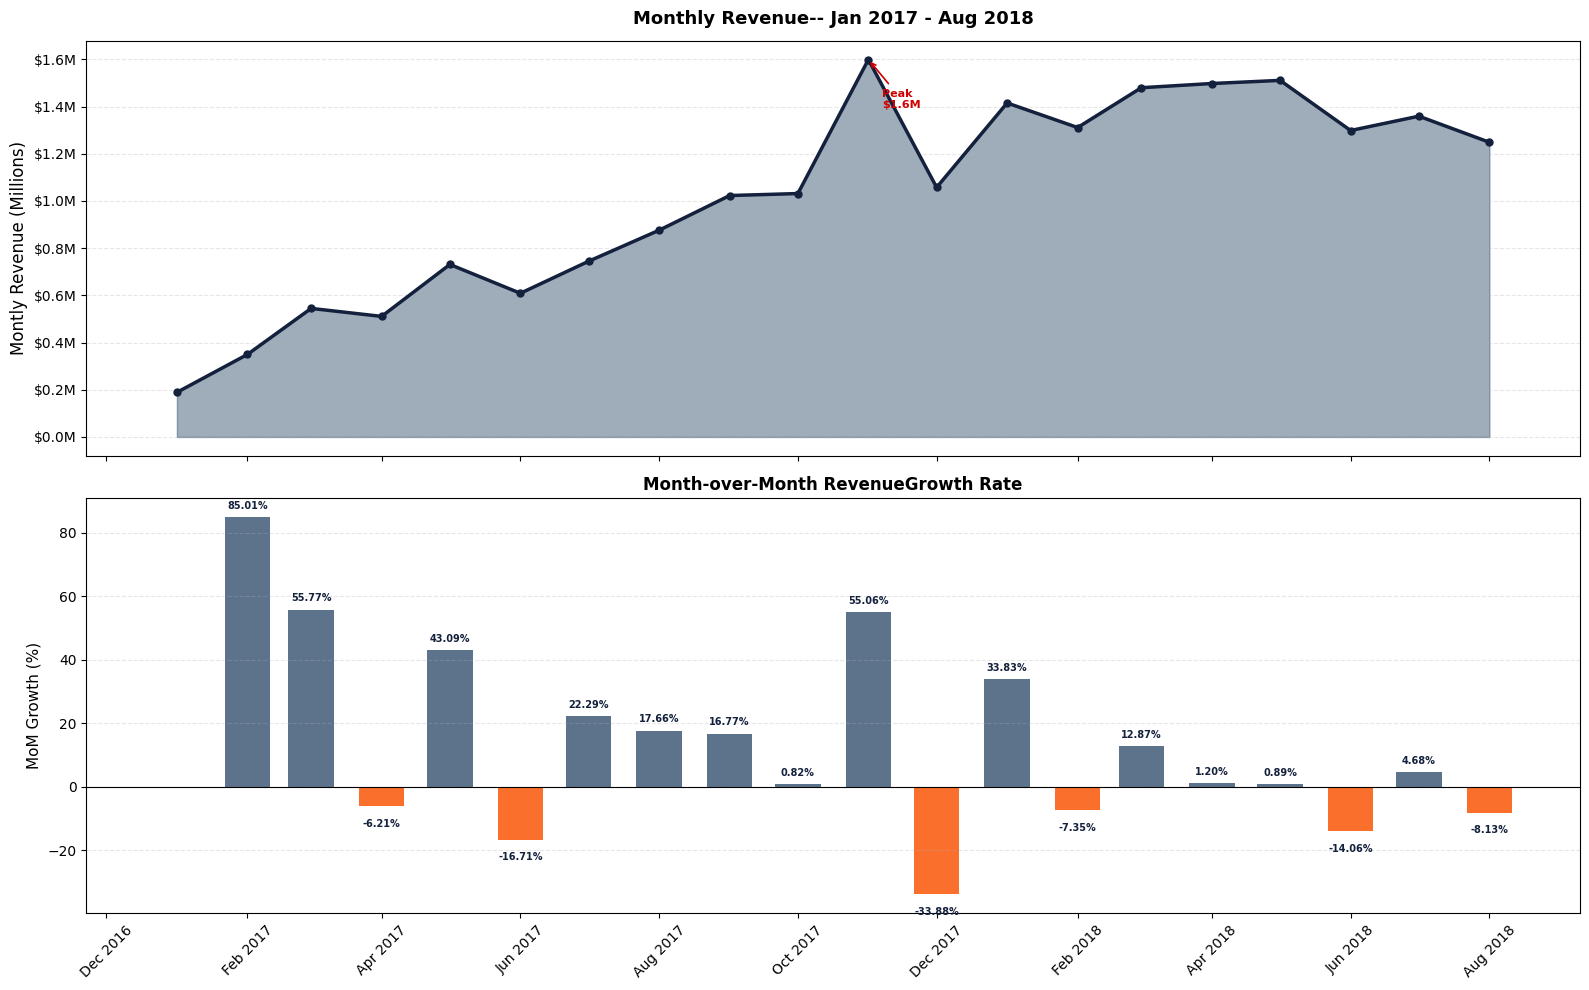

In [11]:
fig, (ax1 , ax2) = plt.subplots(
    2,1,
    figsize=(16,10),
    sharex=True,
  
)

revenue_millions = monthly_revenue['payment_value'] / 1e6
monthly_revenue['order_month'] = pd.to_datetime(monthly_revenue['order_month'])
month_dt = monthly_revenue['order_month']

ax1.plot(
    month_dt, revenue_millions,
    color=COLOUR_PRIMARY, linewidth=2.5,
    marker='o', markersize=5, zorder=3
)

ax1.fill_between(month_dt, revenue_millions, alpha=0.5, color=COLOUR_ACCENT)

peak_ann = monthly_revenue['payment_value'].idxmax()
peak_x = month_dt[peak_ann]
peak_y = revenue_millions[peak_ann]

ax1.annotate(
    f"Peak\n${peak_y:.1f}M",
    xy=(peak_x,peak_y),
    xytext=(10,-35),
    textcoords='offset points',
    fontsize=8, color=COLOUR_EMPHASIS, fontweight='semibold',
    arrowprops=dict(arrowstyle='->' , color=COLOUR_EMPHASIS, lw=1.2)
)

ax1.set_ylabel('Montly Revenue (Millions)', fontsize=12)
ax1.set_title(
    'Monthly Revenue-- '
    'Jan 2017 - Aug 2018',
    fontsize=13, fontweight='bold', pad=12
)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.1f}M') 
)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

growth_data = monthly_revenue['mom_growth_pct'].fillna(0)
bar_colors = [
    COLOUR_ACCENT if x>= 0 else COLOUR_HIGHLIGHT for x in growth_data
]

ax2.bar(month_dt, growth_data, color=bar_colors, width=20 , alpha=0.85)
ax2.axhline(y=0 ,color='black', linewidth=0.8)

for x , y in zip(month_dt, growth_data):
    if y != 0 : ax2.text (
        x,y + (2 if y >= 0 else -4 ),
        f'{y:.2f}%',
        ha='center', va='bottom' if y >= 0 else'top',
        fontsize=7, color=COLOUR_PRIMARY, fontweight='semibold',
    )
        
ax2.set_ylabel('MoM Growth (%)', fontsize=11)
ax2.set_title('Month-over-Month RevenueGrowth Rate', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [12]:
##Checking the stats

master['order_year'] = master['order_purchase_timestamp'].dt.year

yearly_revenue = (
    master
    .groupby('order_year')['payment_value']
    .sum()
    .reset_index()
)
yearly_revenue = yearly_revenue[yearly_revenue['order_year'] != 2016]
yearly_revenue['yoy_growth_pct'] = (
    yearly_revenue['payment_value'].pct_change() * 100
)


print('Year over Year Revenue:')
print('='*50)

for _,row in yearly_revenue.iterrows():
    growth_str = (
        f"     (+ {row['yoy_growth_pct']:.1f}% YoY)"
        if not pd.isna(row['yoy_growth_pct'])
        else ''
    )
    print(f"   {int(row['order_year'])} : "
          f"${row['payment_value']:>12,.2f}{growth_str}")

Year over Year Revenue:
   2017 : $9,266,612.28
   2018 : $11,127,586.12     (+ 20.1% YoY)


In [13]:
master['month_of_year'] = master['order_purchase_timestamp'].dt.month
monthly_avg = (
    master
    .groupby('month_of_year')['payment_value']
    .sum()
    .reset_index()
)

months = {
    1:'Jan' , 2: 'Feb', 3: 'Mar' , 4: 'Apr' , 5:'May' , 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec', 
}

monthly_avg['month'] = monthly_avg['month_of_year'].map(months)

print(f"\nRevenue by Month of year")
print('-'*45)
for _, row in monthly_avg.iterrows():
    bar = '✔' * int(row['payment_value'] / monthly_avg['payment_value'].max() * 30)
                    
    print(f"   {row['month']}: {bar}   ${row['payment_value']:>12,.0f}")


Revenue by Month of year
---------------------------------------------
   Jan: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,604,364
   Feb: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,660,963
   Mar: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   2,024,784
   Apr: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   2,008,735
   May: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   2,242,130
   Jun: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,907,577
   Jul: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   2,104,021
   Aug: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   2,124,967
   Sep: ✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,027,924
   Oct: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,108,215
   Nov: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,599,444
   Dec: ✔✔✔✔✔✔✔✔✔✔✔✔✔✔   $   1,057,602


## Analysis 1 — Revenue Trend: Observations & Findings
 
---
 
### Data Coverage Note
 
The Olist dataset spans September 2016 to October 2018 but only
contains complete monthly data across two time windows:
 
- **2016 (Sep–Dec):** Platform launch period. Excluded from trend
  analysis — partial months with as few as 1 day of orders produce
  astronomically distorted growth rates (e.g. +963,000% MoM).
- **2017 (Jan–Dec):** Full year, 12 complete months. ✓
- **2018 (Jan–Aug):** 8 complete months before dataset truncation. ✓
- **2018 (Sep–Oct):** Excluded — dataset cut off mid-month.
 
**All revenue trend analysis uses 20 complete months (Jan 2017 – Aug 2018).**
 
---
 
### Finding 1 — Strong Year-over-Year Growth
 
Revenue grew from **R$9.27M in 2017 to R$11.13M in 2018 (+20.1% YoY)**.

 Note: Compared to 12 months for 2017, the 2018 statistic only includes 8 months (January through August). 2018 was tracking much higher on an annual basis; projecting the 8-month average forward yields a projected full-year 2018 revenue of around**R$16.7M** indicates actual YoY growth that is closer to **+80%**.

 *Implication: During the dataset period, the company was experiencing robust growth. Inventory planning and revenue-based goals should take the ongoing rising trend into consideration.*

 
### Finding 2 — Black Friday Spike (November 2017)
 
November 2017 recorded the **peak single-month revenue of R$1.6M**,
representing a **+55% spike** above October 2017.
 
This is followed by a sharp -34% correction in December 2017 —
consistent with post-promotional demand exhaustion seen across
most e-commerce markets globally.

*Important disclaimer: The dataset only includes one instance of November and December (2017 only; 2018 equivalents were reduced). Although this result is directionally correct, it cannot be verified as a consistent yearly pattern based only on this dataset.*
 
*Implication: Inventory, logistics capacity, and seller support,should be scaled up in October each year in preparation for the November demand surge.*
 
---
 
### Finding 3 — Mid-Year Strength, Not Classic Seasonality
 
Aggregating revenue by calendar month across both years reveals
**May, August, and July as the three highest-revenue months**
(R$2.24M, R$2.12M, and R$2.10M respectively).
 
In markets in the Northern Hemisphere, this may seem contradictory.
The busiest month for retail is usually December. Brazil's summer months are December through February, which could help to explain some patterns of consumer spending.
 
**Disclaimer on this finding:** September and October appear lower
(R$1.03M and R$1.11M) because they only contain 2017 data —
their 2018 equivalents were excluded due to truncation. Their
bars are not directly comparable to Jan–Aug which contain two
years of data summed.
 
*Implication: Month-of-year revenue patterns for this Brazilian marketplace differ from Northern Hemisphere norms. Marketing and promotional planning should be calibrated to local patterns.*
 
---
 
### Finding 4 — Growth Maturation Through 2018
 
Early 2017 showed explosive MoM growth rates (+85% in Feb 2017,
+55% in Mar 2017) consistent with a platform in early hypergrowth.
 
By 2018 MoM growth had moderated to single digits in most months
(+0.9% in May 2018, +1.2% in Apr 2018), suggesting the platform
was maturing and stabilising at a higher revenue base rather than
continuing to grow exponentially.
 
*Implication: The business appears to be transitioning from acquisition-driven growth to retention-driven growth — making customer lifetime value and churn prediction increasingly important analytical priorities (addressed in Notebooks 02 and 03).*
 
---
 
### Summary 

- Analysis period | Jan 2017 – Aug 2018 (20 months) |
- 2017 total revenue | R$9,266,612 |
- 2018 total revenue (8 months) | R$11,127,586 |
- YoY growth (comparable periods) | +20.1% |
- Peak month | November 2017 — R$1,599,444 |
- Highest MoM growth | February 2017 — +85.0% |
- Largest MoM decline | December 2017 — -33.9% |
- Strongest calendar month | May — R$2,242,130 (2 years summed) |
 
---
*Feeds into: Analysis 3 (Delivery Performance) where we test
whether delivery delays are statistically associated with
review score — a key driver of repeat purchase and revenue.*
"""

---
### Analysis 2 Geography

In [14]:
orders_deduped = master.drop_duplicates(subset='order_id').copy()
print(f"item level: {len(master)}")
print(f"after deduped: {len(orders_deduped):}")
print(f"the difference {len(master) - len(orders_deduped)}")

geo_stats = (
    orders_deduped
    .groupby('customer_state')
    .agg(
        total_orders     = ('order_id' ,'count'),
        total_revenue      = ( 'payment_value', 'sum'),
        avg_order_value  = ('payment_value', 'mean'),
        unique_customers       =('customer_unique_id', 'nunique'),
        avg_review_score       = ('review_score', 'mean'),
    ).reset_index()
)

geo_stats['pct_orders'] = geo_stats['total_orders'] / geo_stats['total_orders'].sum() * 100
geo_stats['pct_revenue'] = geo_stats['total_revenue'] / geo_stats['total_revenue'].sum() * 100

geo_stats = geo_stats.sort_values('total_revenue', ascending=False).reset_index(drop=True)

print('TOP 10 STATES')
print(f"{'State':<8} {'Orders':>8} {'% Orders':>8} {'Revenue':>14} {'% Revenue':>11} {'Avg Order':>10}")
print('='*80)
for _, row in geo_stats.head(10).iterrows():
    print(f" {row['customer_state']:<6} {row['total_orders']:>8,}"
        f"{row['pct_orders']:>9.1f}%   $"
        f"{row['total_revenue']:>12,.0f} "
        f"{row['pct_revenue']:>10.1f}%  $"
        f"{row['avg_order_value']:>8,.0f}" )
    
        

item level: 113425
after deduped: 99441
the difference 13984
TOP 10 STATES
State      Orders % Orders        Revenue   % Revenue  Avg Order
 SP       41,746     42.0%   $   5,998,227       37.5%  $     144
 RJ       12,852     12.9%   $   2,144,380       13.4%  $     167
 MG       11,635     11.7%   $   1,872,257       11.7%  $     161
 RS        5,466      5.5%   $     890,899        5.6%  $     163
 PR        5,045      5.1%   $     811,156        5.1%  $     161
 SC        3,637      3.7%   $     623,086        3.9%  $     171
 BA        3,380      3.4%   $     616,646        3.9%  $     182
 DF        2,140      2.2%   $     355,141        2.2%  $     166
 GO        2,020      2.0%   $     350,092        2.2%  $     173
 ES        2,033      2.0%   $     325,968        2.0%  $     160


In [15]:
top5 = geo_stats.head(5)['pct_revenue'].sum()
top5_orders = geo_stats.head(5)['pct_orders'].sum()

print(f"Top 5 {top5:.1f}% of revenue")
print(f"Top 5 {top5_orders:.1f}% of orders")
print(f" Total states with orders : {len(geo_stats)}")


Top 5 73.2% of revenue
Top 5 77.2% of orders
 Total states with orders : 27


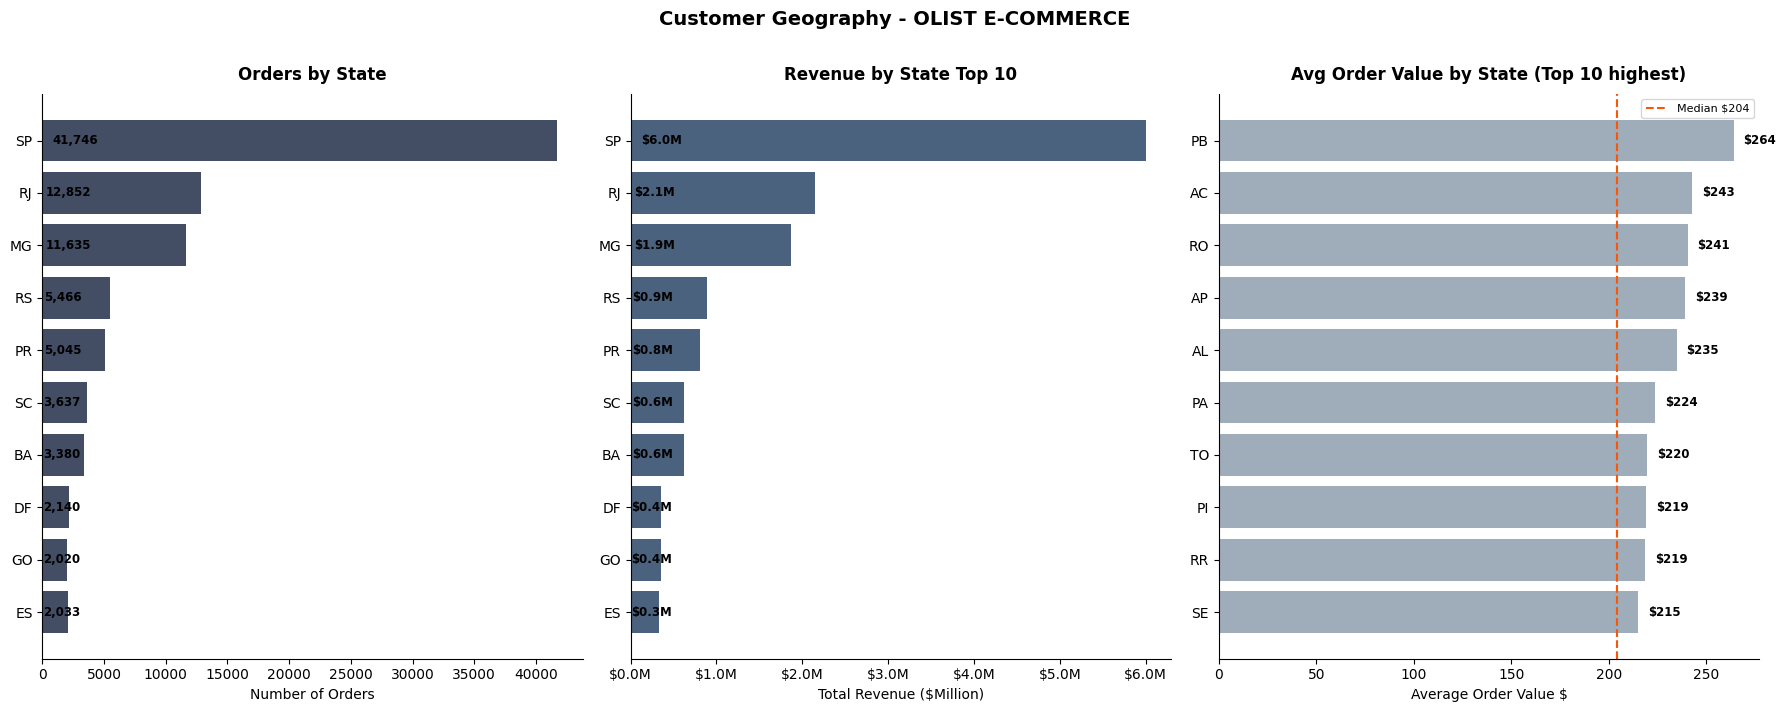

In [16]:
fig , axes = plt.subplots(
    1,3,
    figsize=(18,7)
)

top_n = 10
top_states = geo_stats.head(top_n).copy()

bar1 = axes[0].barh(
    top_states['customer_state'][::-1],
    top_states['total_orders'][::-1],
    color=COLOUR_PRIMARY,
    alpha=0.8,
)

for bar, val in zip(bar1, top_states['total_orders'][::-1]):
    axes[0].text(
        bar.get_width() * 0.02,
        bar.get_y() + bar.get_height()/2,
        f'{val:,}',
        va='center', ha='left',
        fontsize=8.5, color='black', fontweight='bold'
    )
 
axes[0].set_xlabel('Number of Orders')
axes[0].set_title('Orders by State', fontweight='bold', pad=10)
axes[0].set_xlim(0, top_states['total_orders'].max() * 1.05)

bar2 = axes[1].barh(
    top_states['customer_state'][::-1],
    top_states['total_revenue'][::-1]/1e6,
    color=COLOUR_ACCENT,
    alpha=0.95

)

for bar, val in zip(bar2, top_states['total_revenue'][::-1]):
    axes[1].text(
        bar.get_width() * 0.02,
        bar.get_y() + bar.get_height()/2,
        f"${val/1e6:.1f}M",
        va='center', ha='left',
        fontsize=8.5 , color='black', fontweight='bold'
    )

axes[1].set_xlabel('Total Revenue ($Million)')
axes[1].set_title('Revenue by State Top 10', fontweight='bold', pad=10)
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.1f}M')
)

aov_sorted = geo_stats.sort_values('avg_order_value', ascending=True).tail(top_n)
median_aov = geo_stats['avg_order_value'].median()
bar_colors = [
    COLOUR_ACCENT if v >= median_aov else COLOUR_PRIMARY
    for v in aov_sorted['avg_order_value']
]

bar3 = axes[2].barh(
    aov_sorted['customer_state'],
    aov_sorted['avg_order_value'],
    color=bar_colors,
    alpha=0.5
)

for bar, val in zip(bar3, aov_sorted['avg_order_value']):
    axes[2].text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
        f'${val:.0f}',
        va='center', ha='left',
        fontsize=8.5, color='black', fontweight='semibold'
    )
axes[2].axvline(
    color=COLOUR_HIGHLIGHT,
    x=median_aov,
    linewidth=1.5,
    linestyle='--',
    label=f"Median ${median_aov:.0f}"
)

axes[2].legend(fontsize=8)
axes[2].set_xlabel('Average Order Value $')
axes[2].set_title('Avg Order Value by State (Top 10 highest)', fontweight='bold', pad=10)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    'Customer Geography - OLIST E-COMMERCE',
    fontsize=14, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.show()




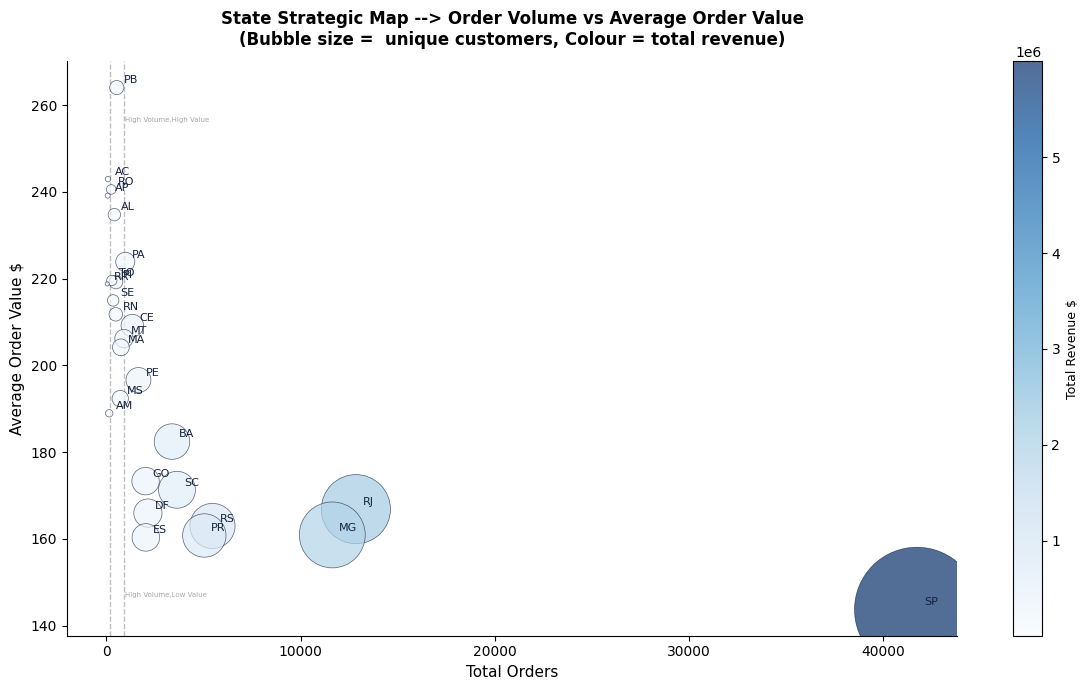

In [17]:
fig, ax = plt.subplots(figsize=(12,7))

scatter =  ax.scatter(
    geo_stats['total_orders'],
    geo_stats['avg_order_value'],
    s=geo_stats['unique_customers'] / 5,
    c=geo_stats['total_revenue'],
    cmap='Blues',
    alpha=0.7,
    edgecolors=COLOUR_PRIMARY,
    linewidths=0.5,
    zorder=3
)

for _, row in geo_stats.iterrows():
    ax.annotate(
        row['customer_state'],
        (row['total_orders'], row['avg_order_value']),
        textcoords='offset points',
        xytext=(5,3),
        fontsize=8,
        color=COLOUR_PRIMARY
    )

median_orders = geo_stats['total_orders'].median()
median_aov = geo_stats['avg_order_value'].median()

ax.axvline(x=median_orders, color='grey', linewidth=1, linestyle='--', alpha=0.5)
ax.axvline(x=median_aov, color='grey', linewidth=1, linestyle='--', alpha=0.5)

ax.text(median_orders * 1.05, geo_stats['avg_order_value'].max() * 0.97,
        'High Volume,High Value', fontsize=5,color='grey',alpha=0.7)

ax.text(median_orders * 1.05, geo_stats['avg_order_value'].min() * 1.02,
        'High Volume,Low Value', fontsize=5,color='grey',alpha=0.7)


cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Total Revenue $', fontsize=9)

ax.set_xlabel('Total Orders', fontsize=11)
ax.set_ylabel('Average Order Value $', fontsize=11)
ax.set_title(
    'State Strategic Map --> Order Volume vs Average Order Value\n'
    '(Bubble size =  unique customers, Colour = total revenue)',
    fontsize=12, fontweight='bold', pad=12
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Analysis 2 — Customer Geography: Observations & Findings
 
---
 
### Finding 1 — Severe Geographic Concentration
 
Revenue is heavily concentrated in a small number of states.
The top 5 states account for approximately **77.2% of all orders
and 73.2% of total revenue** from 27 states with any orders.
 
As the most populous state in Brazil and the hub of the country's e-commerce infrastructure, São Paulo (SP) holds a dominant position.This degree of concentration is a real business risk because it would significantly affect platform revenue in the event of a regional disruption, logistical breakdown, or competitor entry in SP.
 
*Implication: Expansion strategy should prioritise growing
seller and buyer presence in mid-tier states to reduce
concentration risk while the top states remain the revenue base.*
 
---
 
### Finding 2 — Volume vs Value Trade-off
 
The state strategic map reveals an important pattern:
**the highest-volume states are not necessarily the
highest average order value states.**
 
States in the High Volume / High Value quadrant (above median
on both) represent the most strategically valuable geographies.
States in the Low Volume / High Value quadrant are underserved
opportunities ,customers there spend more per order but fewer
of them are on the platform.
 
*Implication: Marketing investment in High Value / Low Volume
states could yield disproportionate revenue returns if seller
coverage and delivery reliability can be established there first.*
 
---
 
### Finding 3 — Regional Average Order Value Variation
 
Average order values vary by approximately $49M between the
highest and lowest spending states (from roughly $264 to $215).
 
This variation likely reflects a combination of:
- Income inequality between Brazilian regions
- Product category mix differences by region
- Shipping cost differences (freight_value included in payment_value)
  — states further from São Paulo pay more in freight which
  mechanically increases their average payment_value
 
*Note: This analysis does not separate product price from
freight — a limitation worth acknowledging. A customer in
a remote state paying $300 for a $200 product plus $100
freight appears identical to a customer in SP paying $300
for a $300 product.*
 
---
 
### Summary Table
 
| Metric | Value |
|--------|-------|
| States with orders | 27 |
| Top state by orders | SP — 41 746 orders (42% of total) |
| Top state by revenue | SP — $5 998 227M (37.5% of total) |
| Top 5 states revenue share | 73.2% |

 
---
 
*Feeds into: Analysis 3 (Delivery Performance) where we examine
whether seller state is associated with delivery delay —
a direct connection to the geographic patterns found here.*

---
### Analysis 3 : Delivary Perfomance 

Business Question :
-  What percentage of orders arrive late ,
- how bad is the delay ,
- and which seller states and products categories have the worst delivery perfomance?



In [21]:
delivered = master[master['order_status'] == 'delivered'].copy()

delivered_orders= delivered.drop_duplicates(subset='order_id').copy()
print(f"item level: {len(master)}")
print(f"after deduped: {len(delivered_orders):}")
print(f"the difference {len(master) - len(delivered_orders)}")



item level: 113425
after deduped: 96478
the difference 16947


In [24]:
late_rate = delivered_orders['was_late'].sum() / len(delivered_orders) *100

print(f"  Total delivered orders {len(delivered_orders):,}")
print(f"   Late orders: {delivered_orders['was_late'].sum():,}")
print(f"   late rate {late_rate:.1f}%")
print(f" On time  {100 - late_rate:.1f}%")

  Total delivered orders 96,478
   Late orders: 6,534
   late rate 6.8%
 On time  93.2%


In [25]:
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,...,payment_count,seller_state,order_month,order_yeah,order_dayofweek,delivery_delay_days,total_item_value,was_late,order_year,month_of_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,...,3.0,SP,2017-10,2017,0,-8.0,38.71,False,2017,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,...,1.0,SP,2018-07,2018,1,-6.0,141.46,False,2018,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,...,1.0,SP,2018-08,2018,2,-18.0,179.12,False,2018,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,...,1.0,MG,2017-11,2017,5,-13.0,72.20,False,2017,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,...,1.0,SP,2018-02,2018,1,-10.0,28.62,False,2018,2


In [38]:
delay_by_state = (
    delivered_orders
    .groupby('seller_state')['delivery_delay_days']
    .mean()
    .sort_values(ascending=False)
    .reset_index()

)

print(delay_by_state.head(11))

   seller_state  delivery_delay_days
0            AM             9.000000
1            SP           -11.125294
2            MA           -11.324742
3            PA           -11.375000
4            RJ           -12.409319
5            BA           -12.615665
6            ES           -13.064935
7            CE           -13.188235
8            DF           -13.297634
9            MG           -13.314502
10           RN           -13.549020


In [39]:
print(f"Mean delivery delay (all states): "
      f"{delivered_orders['delivery_delay_days'].mean():.1f} days")


late_states  = (delay_by_state['delivery_delay_days'] > 0).sum()
early_states = (delay_by_state['delivery_delay_days'] <= 0).sum()
print(f"States with average late delivery:  {late_states}")
print(f"States with average early delivery: {early_states}")


print(f"\nDelivery delay distribution:")
print(delivered_orders['delivery_delay_days'].describe().round(1))

Mean delivery delay (all states): -11.9 days
States with average late delivery:  1
States with average early delivery: 21

Delivery delay distribution:
count    96470.0
mean       -11.9
std         10.2
min       -147.0
25%        -17.0
50%        -12.0
75%         -7.0
max        188.0
Name: delivery_delay_days, dtype: float64


In [43]:
delay_by_category = (
    delivered_orders
    .groupby('product_category_name_english')['delivery_delay_days']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print(delay_by_category.head(10))

       product_category_name_english  delivery_delay_days
0              arts_and_craftmanship            -6.272727
1  furniture_mattress_and_upholstery            -7.162162
2                     home_comfort_2            -7.909091
3                               food            -9.682759
4                       home_confort            -9.864865
5                              audio           -10.011628
6            fashion_underwear_beach           -10.504274
7                         cine_photo           -10.650794
8                             drinks           -10.947183
9                        electronics           -10.978061
